In [29]:
import ast
import pandas as pd 
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading  data set 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] =pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [30]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [31]:
df_DA_US = df_DA_US.dropna(subset = ['salary_year_avg'])
df_DA_US_exploded = df_DA_US.explode('job_skills')
df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [32]:
# Group by skills, aggregate by count and median salary, and sort by highest count
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

# Rename the columns for clarity
df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

# Get total number of data analyst jobs in the US
DA_job_count = len(df_DA_US)

# Calculate the percentage frequency of each skill
df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

# Set your filtering threshold (5%)
percent_threshold = 5

# Filter for high-demand skills using the threshold variable
df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > percent_threshold]

# Display the filtered DataFrame
df_DA_skills_high_demand


,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


NameError: name 'adjust_text' is not defined

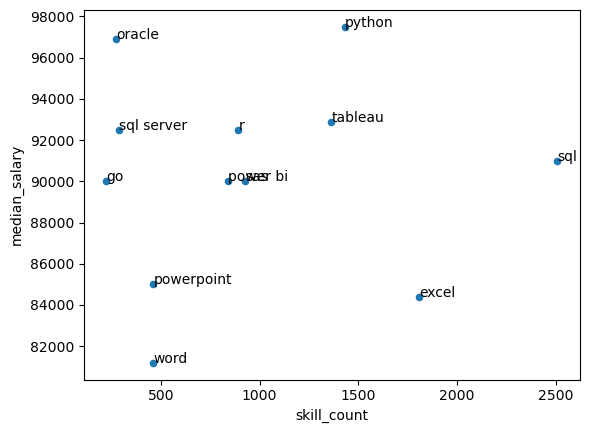

In [25]:


df_DA_skills_high_demand.plot(kind='scatter', x='skill_count', y='median_salary')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_count'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')

# Adjust layout and display plot
plt.tight_layout()
plt.show()


In [35]:
!pip install adjust-text


ERROR: Could not find a version that satisfies the requirement adjust-text (from versions: none)
ERROR: No matching distribution found for adjust-text


NameError: name 'adjust_text' is not defined

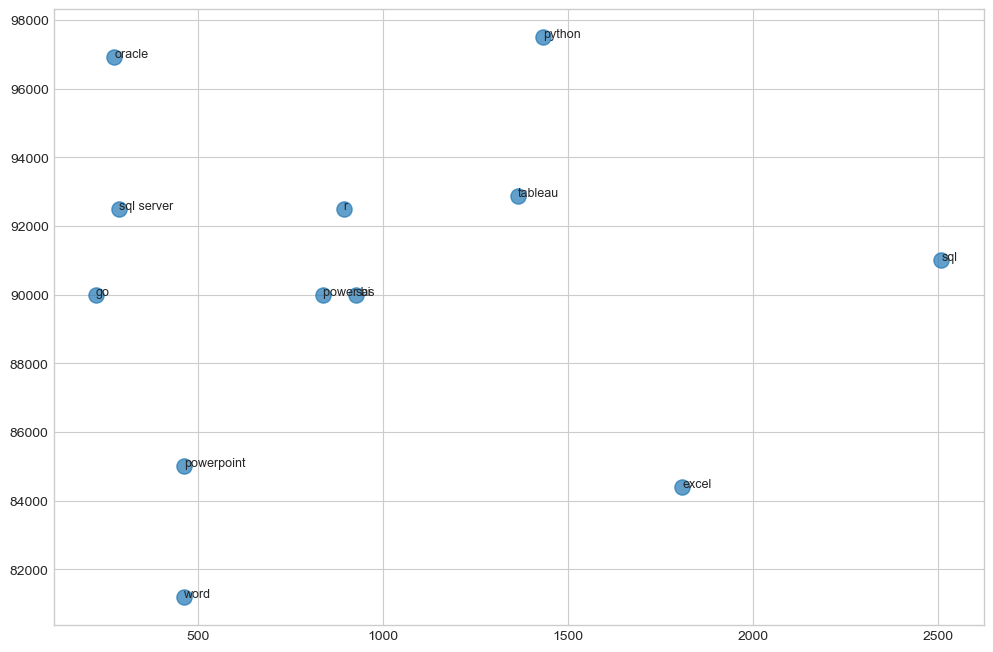

In [36]:


plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
ax.scatter(
    df_DA_skills_high_demand['skill_count'],
    df_DA_skills_high_demand['median_salary'],
    s=120,
    alpha=0.7
)

# Labels for each skill
texts = []

for skill, row in df_DA_skills_high_demand.iterrows():
    texts.append(
        ax.text(
            row['skill_count'],
            row['median_salary'],
            skill,
            fontsize=9
        )
    )

adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='->',
        color='gray',
        lw=0.8
    )
)

# Format salary axis
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'${x/1000:.0f}K')
)

# Labels
ax.set_xlabel(
    'Number of Job Postings',
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    'Median Annual Salary',
    fontsize=12,
    labelpad=10
)

# Title
ax.set_title(
    f'High-Demand Skills: Salary vs Demand\nTop {skill_count} Data Analyst Skills in the US',
    fontsize=16,
    weight='bold',
    pad=20
)

# Clean up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()